In [1]:
# # Inspect Original ERA5 `.npy` Dataset

In [3]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置显示字体为 Times New Roman
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams["axes.unicode_minus"] = False

#图像清晰度调整
%config InlineBackend.figure_format = 'retina'

In [5]:
# %%
DATA_DIR = Path("/Users/camus/Desktop/dissertation/meeting1/RainfallWestAfrica_Resources")
runid = "ERA5"

variable_names = [
    "Precip",
    "VImoistureDivergence",
    "VIwater",
    "CloudCover",
    "EvaporationRate",
    "SkinTemperature",
    "SeaLevelPressure",
    "10mWindSpeed",
]

In [6]:
# %%
def inspect_npy(name):
    path = DATA_DIR / f"{runid}_{name}_regr_onescale.npy"
    arr = np.load(path)

    info = {
        "variable": name,
        "file": path.name,
        "shape": arr.shape,
        "dtype": arr.dtype,
        "min": np.nanmin(arr),
        "max": np.nanmax(arr),
        "mean": np.nanmean(arr),
        "std": np.nanstd(arr),
        "nan_count": np.isnan(arr).sum(),
    }

    return arr, info

In [7]:
# %%
arrays = {}
info_list = []

for name in variable_names:
    arr, info = inspect_npy(name)
    arrays[name] = arr
    info_list.append(info)

dataset_info_df = pd.DataFrame(info_list)
dataset_info_df

,variable,file,shape,dtype,min,max,mean,std,nan_count
0,Precip,ERA5_Precip_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.173186,0.128656,0
1,VImoistureDivergence,ERA5_VImoistureDivergence_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.751166,0.121924,0
2,VIwater,ERA5_VIwater_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.640285,0.160719,0
3,CloudCover,ERA5_CloudCover_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.572744,0.185634,0
4,EvaporationRate,ERA5_EvaporationRate_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.537442,0.155647,0
5,SkinTemperature,ERA5_SkinTemperature_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.344939,0.156197,0
6,SeaLevelPressure,ERA5_SeaLevelPressure_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.520559,0.125340,0
7,10mWindSpeed,ERA5_10mWindSpeed_regr_onescale.npy,"(344, 11, 13)",float64,0.0,1.0,0.440884,0.210052,0


In [8]:
# %% [markdown]
# ## Time Dimension Information

In [9]:
# %%
n_time = arrays["Precip"].shape[0]

print("Number of timesteps:", n_time)
print("Number of years if monthly data:", n_time / 12)
print("Number of years if JJAS-only data:", n_time / 4)

Number of timesteps: 344
Number of years if monthly data: 28.666666666666668
Number of years if JJAS-only data: 86.0


In [10]:
# %%
# The starting-point script predicts September 2025 using the final timestep.
# Therefore, we infer the date range by assuming the last timestep is September 2025.

dates = pd.date_range(
    end="2025-09-01",
    periods=n_time,
    freq="MS"
)

print("Inferred start date:", dates[0].strftime("%Y-%m"))
print("Inferred end date:", dates[-1].strftime("%Y-%m"))

Inferred start date: 1997-02
Inferred end date: 2025-09


In [11]:
# %%
date_info_df = pd.DataFrame({
    "time_index": np.arange(n_time),
    "date": dates,
    "year": dates.year,
    "month": dates.month,
})

date_info_df.head(), date_info_df.tail()

(   time_index       date  year  month
 0           0 1997-02-01  1997      2
 1           1 1997-03-01  1997      3
 2           2 1997-04-01  1997      4
 3           3 1997-05-01  1997      5
 4           4 1997-06-01  1997      6,
      time_index       date  year  month
 339         339 2025-05-01  2025      5
 340         340 2025-06-01  2025      6
 341         341 2025-07-01  2025      7
 342         342 2025-08-01  2025      8
 343         343 2025-09-01  2025      9)

In [12]:
# %%
month_counts = date_info_df["month"].value_counts().sort_index()

month_counts_df = pd.DataFrame({
    "month": month_counts.index,
    "count": month_counts.values
})

month_counts_df

,month,count
0,1,28
1,2,29
2,3,29
3,4,29
4,5,29
5,6,29
6,7,29
7,8,29
8,9,29
9,10,28


In [14]:
# ## Check Whether the Data Contains All Months or Only Monsoon Months

In [15]:
# %%
jjas_months = [6, 7, 8, 9]

n_jjas = date_info_df["month"].isin(jjas_months).sum()
n_non_jjas = n_time - n_jjas

print("JJAS samples:", n_jjas)
print("Non-JJAS samples:", n_non_jjas)

if n_non_jjas == 0:
    print("This dataset appears to contain only JJAS monsoon-season months.")
else:
    print("This dataset appears to contain all/continuous monthly data, not only JJAS.")

JJAS samples: 116
Non-JJAS samples: 228
This dataset appears to contain all/continuous monthly data, not only JJAS.


In [16]:
# %%
jjas_years = (
    date_info_df[date_info_df["month"].isin(jjas_months)]
    .groupby("year")["month"]
    .agg(list)
)

complete_jjas_years = jjas_years[
    jjas_years.apply(lambda months: set(months) == set(jjas_months))
]

print("Number of complete JJAS seasons:", len(complete_jjas_years))
print("First complete JJAS year:", complete_jjas_years.index.min())
print("Last complete JJAS year:", complete_jjas_years.index.max())

Number of complete JJAS seasons: 29
First complete JJAS year: 1997
Last complete JJAS year: 2025


In [17]:
# ## Spatial Grid Information

In [18]:
# %%
# Based on the preprocessing starting point:
# input grid: latitudes -2 to 18, step 2
# input grid: longitudes -33 to 3, step 3

input_lats = np.arange(-2, 20, 2)
input_lons = np.arange(-33, 6, 3)

print("Input latitudes:", input_lats)
print("Input longitudes:", input_lons)
print("Number of latitudes:", len(input_lats))
print("Number of longitudes:", len(input_lons))


Input latitudes: [-2  0  2  4  6  8 10 12 14 16 18]
Input longitudes: [-33 -30 -27 -24 -21 -18 -15 -12  -9  -6  -3   0   3]
Number of latitudes: 11
Number of longitudes: 13


In [19]:
# %%
# Rainfall target used in the CNN was cropped:
# precip[:, 1:-1, 1:-1]

target_lats = input_lats[1:-1]
target_lons = input_lons[1:-1]

print("Target latitudes after cropping:", target_lats)
print("Target longitudes after cropping:", target_lons)
print("Target grid shape:", len(target_lats), "x", len(target_lons))

Target latitudes after cropping: [ 0  2  4  6  8 10 12 14 16]
Target longitudes after cropping: [-30 -27 -24 -21 -18 -15 -12  -9  -6  -3   0]
Target grid shape: 9 x 11


In [20]:
# ## Regional Mean Time Series for Each Variable

In [21]:
# %%
regional_mean_df = pd.DataFrame({
    "date": dates,
    "year": dates.year,
    "month": dates.month,
})

for name in variable_names:
    arr = arrays[name]
    regional_mean_df[name] = arr.mean(axis=(1, 2))

regional_mean_df.head()

,date,year,month,Precip,VImoistureDivergence,VIwater,CloudCover,EvaporationRate,SkinTemperature,SeaLevelPressure,10mWindSpeed
0,1997-02-01,1997,2,0.152299,0.774599,0.625285,0.518791,0.533138,0.409147,0.577774,0.471059
1,1997-03-01,1997,3,0.154832,0.767460,0.588407,0.494509,0.529223,0.374252,0.648024,0.458448
2,1997-04-01,1997,4,0.186357,0.739115,0.644967,0.572442,0.510273,0.361360,0.578025,0.442027
3,1997-05-01,1997,5,0.146328,0.778827,0.601570,0.506517,0.524344,0.386173,0.544779,0.408828
4,1997-06-01,1997,6,0.134687,0.783615,0.611420,0.482444,0.576405,0.412034,0.626498,0.454245


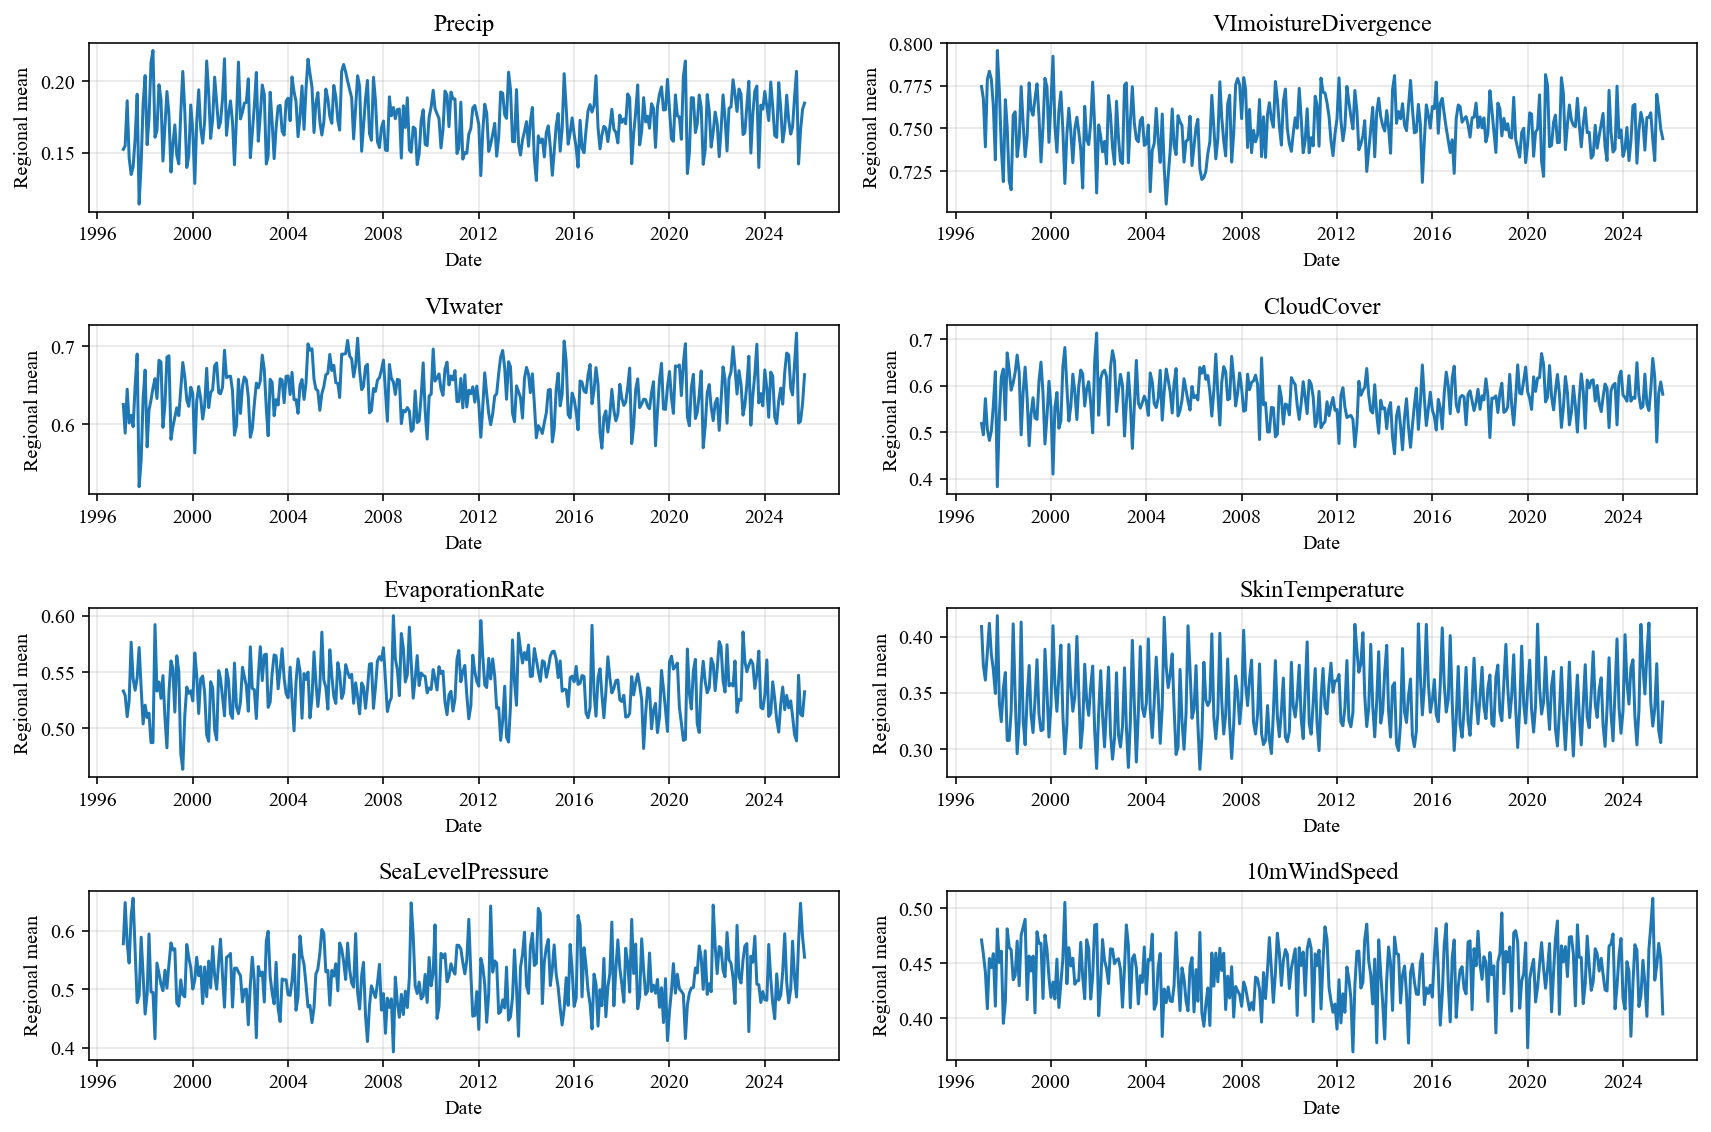

In [22]:
# %%
plt.figure(figsize=(12, 8))

for i, name in enumerate(variable_names, start=1):
    plt.subplot(4, 2, i)
    plt.plot(regional_mean_df["date"], regional_mean_df[name])
    plt.title(name)
    plt.xlabel("Date")
    plt.ylabel("Regional mean")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ## Monthly Climatology of Regional Mean Values

In [24]:
# %%
monthly_climatology = {}

for name in variable_names:
    monthly_climatology[name] = (
        regional_mean_df
        .groupby("month")[name]
        .agg(["mean", "std", "min", "max"])
    )

monthly_climatology["Precip"]

,mean,std,min,max
month,,,,
1,0.180401,0.012079,0.153689,0.203992
2,0.158645,0.015770,0.128428,0.193720
3,0.165985,0.013071,0.139842,0.203036
4,0.187167,0.011227,0.167972,0.213179
5,0.179683,0.020980,0.145480,0.221574
6,0.154637,0.014900,0.130505,0.206497
7,0.166295,0.011956,0.139838,0.200053
8,0.187023,0.014568,0.157173,0.214258
9,0.183604,0.013472,0.156130,0.214180


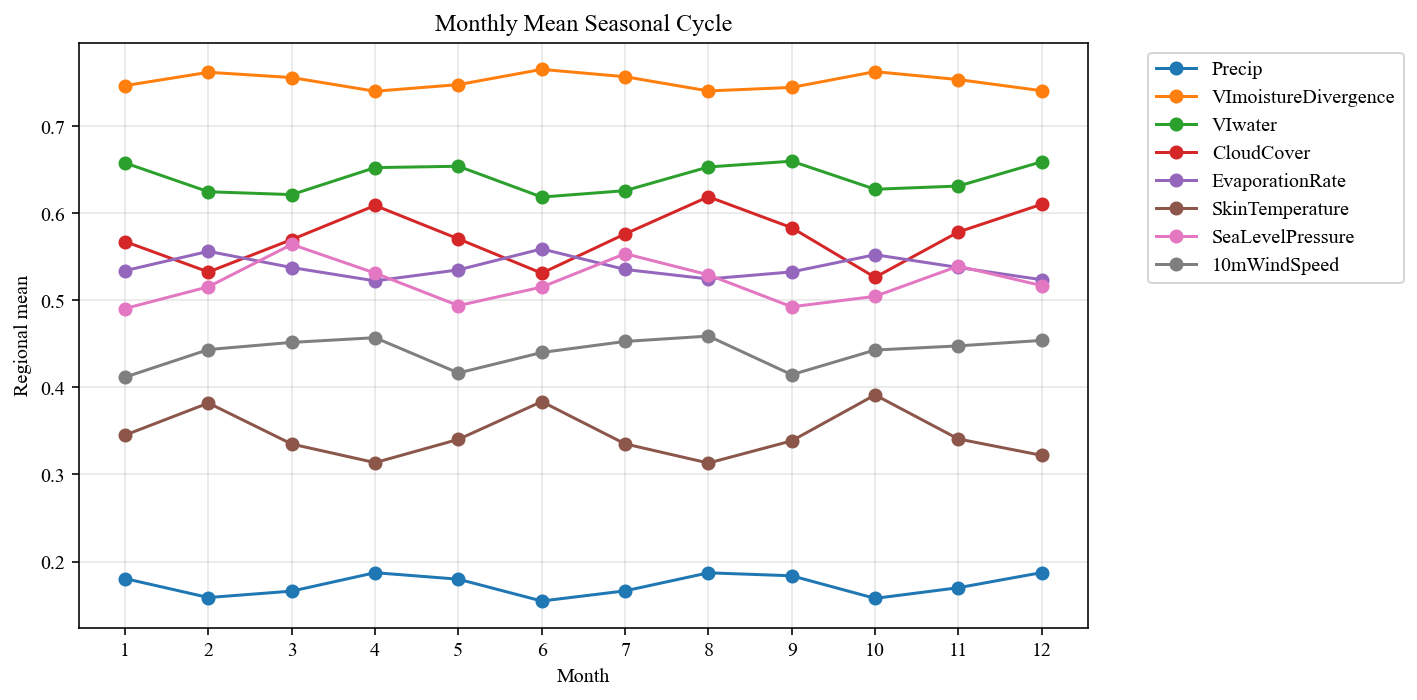

In [25]:
# %%
plt.figure(figsize=(10, 5))

for name in variable_names:
    monthly_mean = regional_mean_df.groupby("month")[name].mean()
    plt.plot(monthly_mean.index, monthly_mean.values, marker="o", label=name)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Regional mean")
plt.title("Monthly Mean Seasonal Cycle")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# %% [markdown]
# ## Correlation Between Regional Mean Variables and Rainfall

In [27]:
# %%
corr_df = regional_mean_df[variable_names].corr()

corr_df

,Precip,VImoistureDivergence,VIwater,CloudCover,EvaporationRate,SkinTemperature,SeaLevelPressure,10mWindSpeed
Precip,1.000000,-0.956310,0.743439,0.828779,-0.515721,-0.482383,-0.287316,-0.022564
VImoistureDivergence,-0.956310,1.000000,-0.689213,-0.772276,0.373514,0.458465,0.257771,0.051355
VIwater,0.743439,-0.689213,1.000000,0.602789,-0.249202,-0.158764,-0.282055,-0.193203
CloudCover,0.828779,-0.772276,0.602789,1.000000,-0.494186,-0.582795,-0.229955,0.130568
EvaporationRate,-0.515721,0.373514,-0.249202,-0.494186,1.000000,0.348864,0.041977,-0.360842
SkinTemperature,-0.482383,0.458465,-0.158764,-0.582795,0.348864,1.000000,-0.168605,-0.217965
SeaLevelPressure,-0.287316,0.257771,-0.282055,-0.229955,0.041977,-0.168605,1.000000,0.306502
10mWindSpeed,-0.022564,0.051355,-0.193203,0.130568,-0.360842,-0.217965,0.306502,1.000000


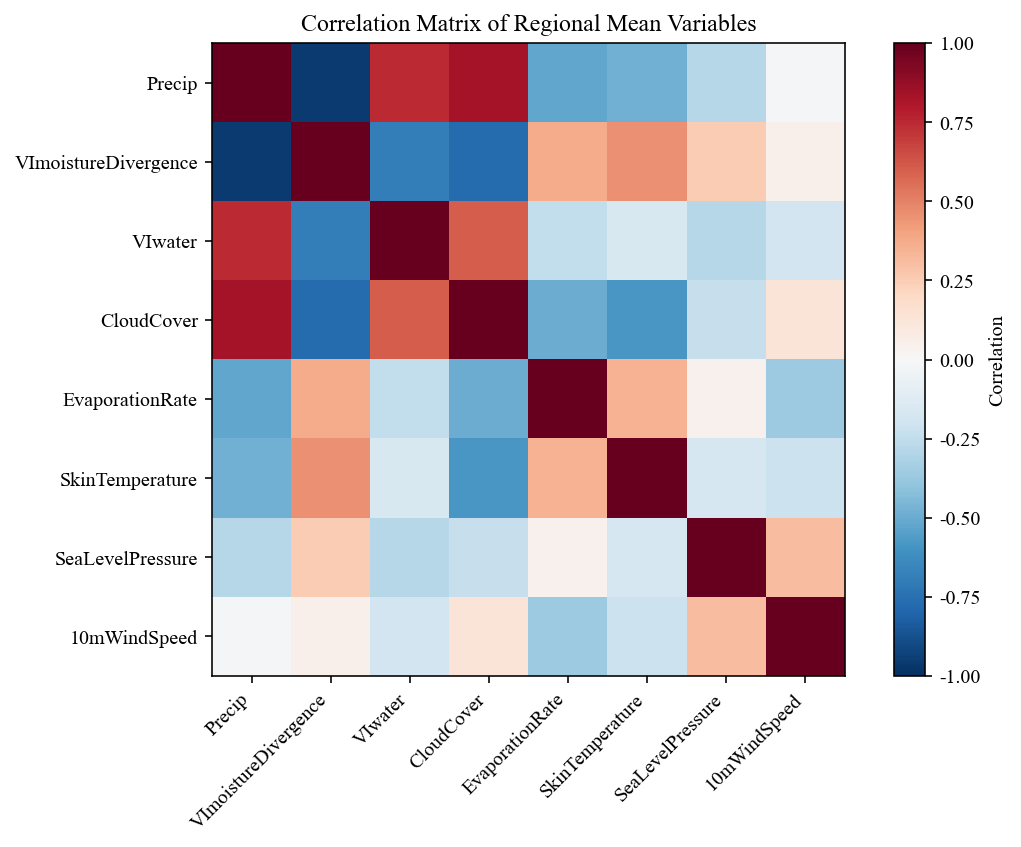

In [28]:
# %%
plt.figure(figsize=(8, 6))
plt.imshow(corr_df, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(variable_names)), variable_names, rotation=45, ha="right")
plt.yticks(range(len(variable_names)), variable_names)

plt.title("Correlation Matrix of Regional Mean Variables")
plt.tight_layout()
plt.show()

In [33]:
# %%
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_

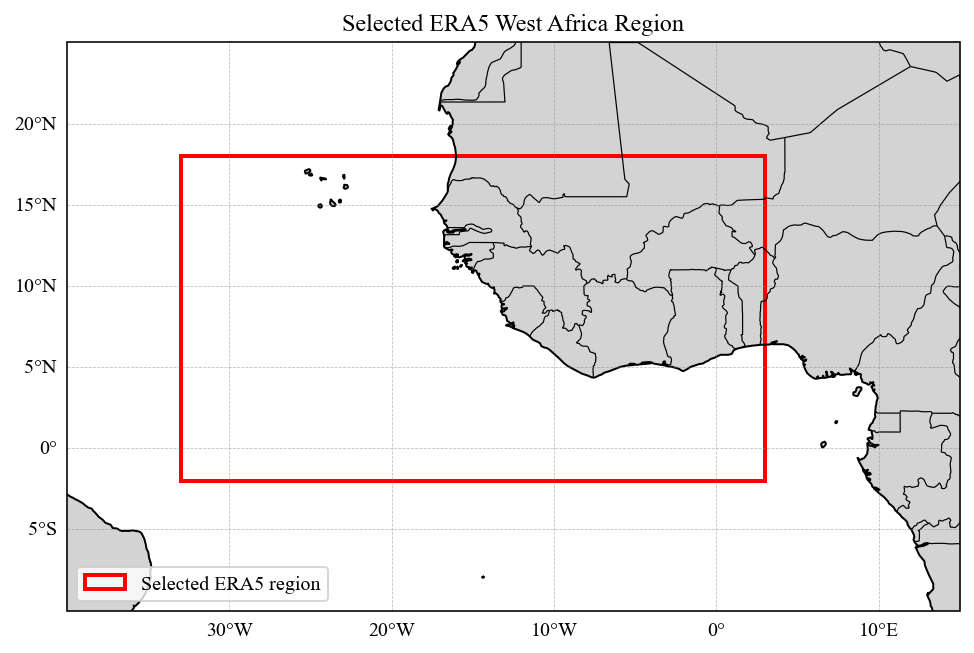

In [34]:
# %%
# Dataset selected region from preprocessing script
lon_min, lon_max = -33, 3
lat_min, lat_max = -2, 18

plt.figure(figsize=(8, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

# Show wider West Africa area
ax.set_extent([-40, 15, -10, 25], crs=ccrs.PlateCarree())

ax.coastlines(resolution="50m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# Draw selected data region
rect = Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    transform=ccrs.PlateCarree(),
    label="Selected ERA5 region"
)

ax.add_patch(rect)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

plt.title("Selected ERA5 West Africa Region")
plt.legend(loc="lower left")
plt.show()